

# Final-Exam-2510 Hint Code & Setup

Final-Exam-2510 is the official hint code for the midterm. Many exam questions are based on it.

**Before the exam**

*  Mount your Google Drive in Colab.

*  Place exam-customer.csv in a folder you can access from the Drive mount (e.g., /content/drive/MyDrive/final/).

* Open Final-exam-2510, update the file path to the CSV if needed, and make sure the notebook runs end-to-end without errors.

**During the exam**

* You will run the hint code and **edit/modify/expand** it to answer the questions.


If you can run the notebook and load exam-customer.csv from your Drive mount, you’re ready.




In [ ]:
#mounnt your google dirve
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
myData = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2510/2510-MH/Final-Exam/exam-customer.csv')
myData.head(n=10)

,CustID,Sex,Race,BirthDate,College,HouseholdSize,ZipCode,Income,Spending2020,Spending2021,NumOfOrders,DaysSinceLast,Satisfaction,Channel
0,1530016,Female,Black,12/16/1986,Yes,5,90047,53000,287.0,241.0,3,101,Very Dissatisfied,SM
1,1531136,Male,White,5/9/1993,Yes,5,90026,94000,1227.0,843.0,12,262,Neutral,TV
2,1532160,Male,Black,5/22/1966,Yes,2,90027,64000,523.0,719.0,9,122,Very Satisfied,TV
3,1532307,Male,White,9/16/1964,Yes,4,90029,60000,516.0,582.0,13,129,Very Dissatisfied,SM
4,1532356,Female,Hispanic,7/15/1964,No,5,90017,47000,555.0,845.0,7,97,Very Dissatisfied,Web
5,1532387,Male,White,8/27/1957,Yes,2,90028,67000,631.0,452.0,9,150,Neutral,SM
6,1533017,Female,Hispanic,5/14/1985,Yes,3,90063,84000,229.0,153.0,2,144,Very Satisfied,Web
7,1533561,Male,Hispanic,2/10/1981,Yes,5,90050,76000,1474.0,1079.0,23,122,Very Satisfied,Referral
8,1533697,Female,Asian,10/8/1974,Yes,3,90038,42000,300.0,247.0,3,238,Very Satisfied,Web
9,1533766,Male,Hispanic,9/16/1971,Yes,2,90057,71000,925.0,708.0,4,171,Neutral,TV


In [ ]:
#Mean or median of the column Income?
myData['Income'].mean() #or median(), max(), min()


np.float64(73036.5296803653)

### Row Subsetting using boolean expression



In [ ]:
#high_spending_cust = (myData['Spending2020'] > 800 ) &  (myData['Spending2021'] > 800) # and operator & is used here


high_spending_cust = myData[ (myData['Spending2020'] > 1000) |  (myData['Spending2021'] > 1000)  ] # or operator | is used

# & --> and operator,   | --> or operator


high_spending_cust

,CustID,Sex,Race,BirthDate,College,HouseholdSize,ZipCode,Income,Spending2020,Spending2021,NumOfOrders,DaysSinceLast,Satisfaction,Channel
1,1531136,Male,White,5/9/1993,Yes,5,90026,94000,1227.0,843.0,12,262,Neutral,TV
7,1533561,Male,Hispanic,2/10/1981,Yes,5,90050,76000,1474.0,1079.0,23,122,Very Satisfied,Referral
10,1533791,Male,White,10/27/1999,Yes,1,90060,97000,828.0,1028.0,17,110,Very Dissatisfied,Web
17,1535927,Male,White,1/12/1979,Yes,1,90003,66000,1283.0,879.0,10,35,Very Satisfied,Referral
18,1536475,Male,Pacific Islander,5/17/1958,Yes,2,90019,73000,1276.0,1108.0,20,56,Neutral,Web
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,1576752,Male,Black,7/18/1968,Yes,4,90044,82000,1322.0,1241.0,11,159,Very Satisfied,TV
211,1577940,Female,Black,2/27/1973,Yes,5,90019,94000,634.0,1206.0,18,181,Somewhat Satisfied,Web
212,1578327,Male,Hispanic,8/24/1967,Yes,1,90024,49000,1015.0,760.0,11,136,Neutral,SM
214,1578525,Male,Hispanic,12/12/1963,Yes,1,90005,82000,NaN,1121.0,25,302,Somewhat Satisfied,Web


In [19]:
# Find the royal customers who are female and spending in year 2021 is greater than 1200
female_royal_cust_true_false = (myData['Sex'] == 'Female') & (myData['Spending2021']> 1200)
myData[female_royal_cust_true_false]

,CustID,Sex,Race,BirthDate,College,HouseholdSize,ZipCode,Income,Spending2020,Spending2021,NumOfOrders,DaysSinceLast,Satisfaction,Channel
192,1577940,Female,Black,2/27/1973,Yes,5,90019,94000,634.0,1206.0,18,181,Somewhat Satisfied,Web
211,1577940,Female,Black,2/27/1973,Yes,5,90019,94000,634.0,1206.0,18,181,Somewhat Satisfied,Web


In [ ]:
high_spending_cust.shape # or len(high_spending_cust)

(64, 14)

### Groupby

In [ ]:
#from this, what can we infer?
#Find the average spending of 2020 for the customers who are referred by each channel (e.g., Referral, SM, TV and Web)

myData.groupby('Channel')['Spending2020'].mean()



,Spending2020
Channel,
Referral,629.097561
SM,673.000000
TV,693.824561
Web,597.915493


In [ ]:
# For each household size (e.g., 1 person, 2 people, 3 people, etc.), calculate the average income of customers in that group?

#Hint -> myData.groupby('HouseholdSize')....

In [22]:
#standard deviation of the Income column
# by default, std() returns the sample standard deviation.
# Note: std(ddof = 0) returns a population standard dev.

myData.Income.std()

24060.29388910448

### Can you find the correlation Coefficient (r) or covirance between "HouseholdSize" and "Income"?

In [23]:
myData[['Income', 'HouseholdSize']].corr()

,Income,HouseholdSize
Income,1.000000,0.163175
HouseholdSize,0.163175,1.000000


In [24]:
myData[['Income', 'HouseholdSize']].cov()

,Income,HouseholdSize
Income,5.788977e+08,5611.495120
HouseholdSize,5.611495e+03,2.042897


In [25]:
# Any missing values?

myData.isnull().sum()



,0
CustID,0
Sex,0
Race,0
BirthDate,0
College,0
HouseholdSize,0
ZipCode,0
Income,0
Spending2020,7
Spending2021,5


#### How to replace the missing values? --> look at ch2.ipynb file --> fillna

In [ ]:
# replace the missing values in the column Spending2021 with its mean --> fillna

imputation = myData.Spending2021.fillna(myData.Spending2021.mean()) #still original dataframe myData remains unchanged.
imputation

#To permanently change the original data frame, myData:

# myData['Spending2021'] = myData.Spending2021.fillna(myData.Spending2021.mean()) -> Be careful! -> this will change your original dataframe forever~


,Spending2021
0,241.0
1,843.0
2,719.0
3,582.0
4,845.0
...,...
214,1121.0
215,397.0
216,514.0
217,586.0


## Bar chart - Categorical variables

In [26]:
Gender_freq = myData['Sex'].value_counts()
Gender_freq

,count
Sex,
Male,139
Female,80


In [27]:
Gender_freq_proportion = myData['Sex'].value_counts(normalize = True)
Gender_freq_proportion

,proportion
Sex,
Male,0.634703
Female,0.365297


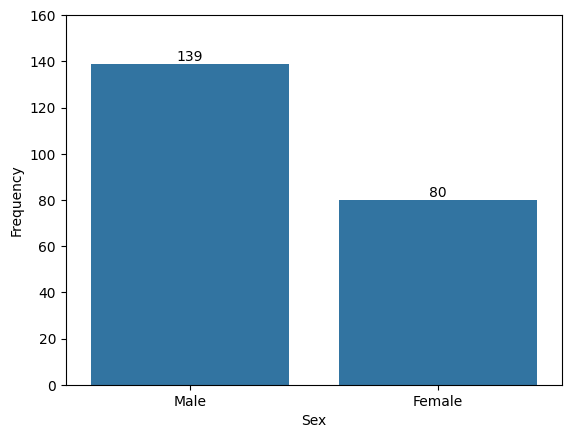

In [28]:
import seaborn as sns

ax = sns.barplot(x = Gender_freq.index,
                 y = Gender_freq.values)

ax.set(ylim = (0, 160),
       ylabel = 'Frequency')

ax.bar_label(ax.containers[0]);  # add labels in the graph (140, 60, for example)


## Histograms for numerical variables!


In [30]:
# First find out min and max for Income for creating bins (start and stop values)
print(myData.Income.max())
print(myData.Income.min())

167000
31000


In [31]:
import numpy as np
intervals = np.linspace(start = 30000, stop = 170000, num = 11)
print("intervals:  ", intervals)
# num 11 --> 11 evenly spaced numbers create 10 equal-width bins
#        --> 11 edges/numbers define 10 equal-width bins




#pd.cut(....):  turns your numerical column into categorial categorial bins
#.value_counts(...): then counts how many rows fall in each bin.

Frequency = pd.cut(myData.Income, bins = np.linspace(30000, 170000, 11)).value_counts(sort = False)

Frequency

intervals:   [ 30000.  44000.  58000.  72000.  86000. 100000. 114000. 128000. 142000.
 156000. 170000.]


,count
Income,
"(30000.0, 44000.0]",22
"(44000.0, 58000.0]",52
"(58000.0, 72000.0]",46
"(72000.0, 86000.0]",34
"(86000.0, 100000.0]",43
"(100000.0, 114000.0]",13
"(114000.0, 128000.0]",2
"(128000.0, 142000.0]",4
"(142000.0, 156000.0]",2


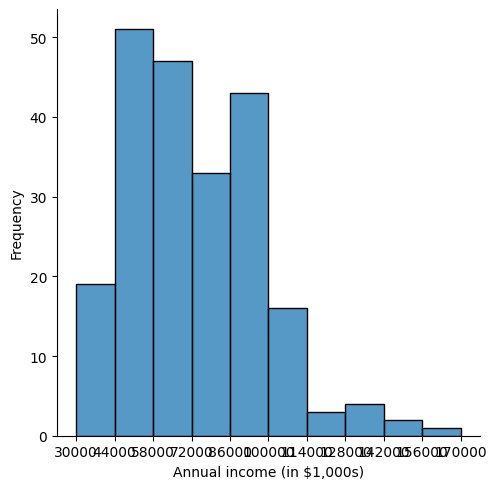

In [33]:
import seaborn as sns
ax = sns.displot(myData.Income,
                 bins = np.linspace(30000, 170000, 11))

ax.set(xticks = intervals,
       xlabel = 'Annual income (in $1,000s)',
       ylabel = 'Frequency')

### The above plot --> Positively skewed

## Regression (Ch7)

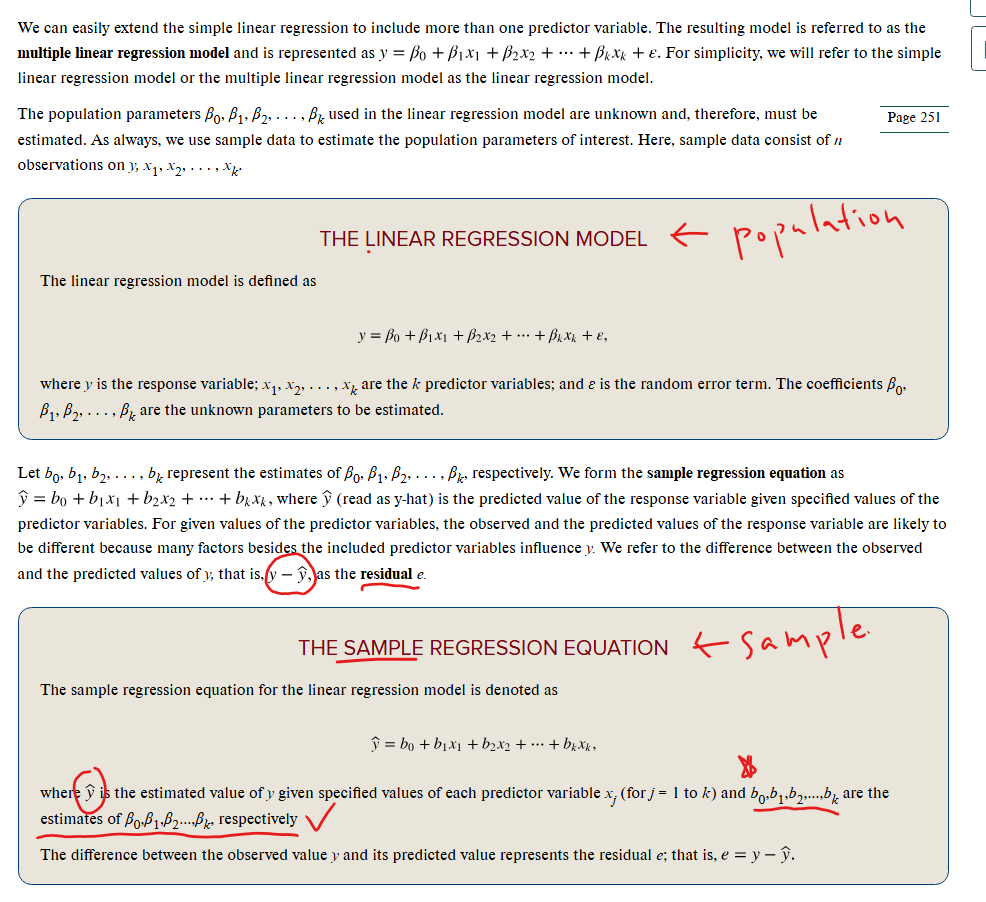

In [36]:
import statsmodels.formula.api as smf
Model = smf.ols('Spending2021 ~ Income + NumOfOrders', data = myData).fit()
print(Model.summary())

                            OLS Regression Results                            
Dep. Variable:           Spending2021   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                     78.31
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           3.64e-26
Time:                        20:52:27   Log-Likelihood:                -1496.2
No. Observations:                 214   AIC:                             2998.
Df Residuals:                     211   BIC:                             3008.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     325.4672     62.731      5.188      

Intepretation of the above summary table?


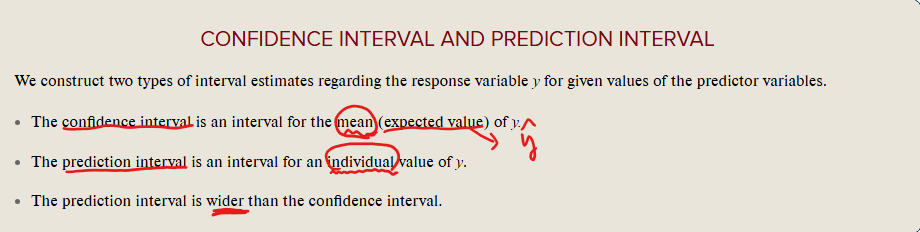